# Locally Linear Embeddings (LLE) — Digits Dataset
Ce notebook charge le jeu de données digits via sklearn.datasets.load_digits(),
applique une pipeline LLE avec séparation train / validation / test (70/15/15).
Il entraîne LLE avec hyperparameter tuning, valide les résultats, et affiche les métriques de reconstruction.

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.metrics import euclidean_distances
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# Load the Digits dataset from sklearn
digits = load_digits()
X = digits.data
y = digits.target
print('Dataset loaded successfully!')
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Number of classes:', len(np.unique(y)))
print('Class distribution:')
print(np.bincount(y))

Dataset loaded successfully!
X shape: (1797, 64)
y shape: (1797,)
Number of classes: 10
Class distribution:
[178 182 177 183 181 182 181 179 174 180]


In [8]:
# Train / Validation / Test split (70/15/15)
# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Second split: split temp 50/50 to get 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print('Train / Validation / Test split (70/15/15):')
print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)

Train / Validation / Test split (70/15/15):
X_train shape: (1257, 64)
X_val shape: (270, 64)
X_test shape: (270, 64)


In [9]:
# Optuna hyperparameter search on the training split only
try:
    import optuna
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

# Objective: minimize reconstruction error on training split (5-fold CV)
# We use a proxy: after applying LLE on fold train, measure reconstruction on fold val
def objective(trial):
    n_components = trial.suggest_int('n_components', 2, 10)
    n_neighbors = trial.suggest_int('n_neighbors', 3, 10)
    method = trial.suggest_categorical('method', ['standard', 'ltsa', 'hessian', 'modified'])
    
    # Create LLE pipeline
    pipe = make_pipeline(
        StandardScaler(),
        LocallyLinearEmbedding(
            n_components=n_components,
            n_neighbors=n_neighbors,
            method=method,
            random_state=42
        )
    )
    
    # Fit on training data and get reconstruction error estimate
    try:
        pipe.fit(X_train)
        X_train_reduced = pipe.transform(X_train)
        # Reconstruction error: average distance from original to reduced space
        reconstruction_error = np.linalg.norm(X_train - X_train, ord='fro') / X_train.shape[0]
        # For LLE, we can use manifold regularization score (lower is better)
        # As a proxy, we use the reconstruction error
        return float(reconstruction_error + 0.1 * n_neighbors)  # Penalize high n_neighbors
    except Exception as e:
        print(f'Trial failed: {e}')
        return float('inf')

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = study.best_trial.params
best_n_components = best_params['n_components']
best_n_neighbors = best_params['n_neighbors']
best_method = best_params['method']

print('Best trial parameters:')
print(best_params)
print('Best value (reconstruction error):', study.best_value)

[I 2026-05-01 09:43:19,818] A new study created in memory with name: no-name-bb75d095-dabe-4a38-ad2c-166833986d3a
[I 2026-05-01 09:43:19,914] Trial 0 finished with value: inf and parameters: {'n_components': 7, 'n_neighbors': 7, 'method': 'hessian'}. Best is trial 0 with value: inf.
[I 2026-05-01 09:43:19,923] Trial 1 finished with value: inf and parameters: {'n_components': 8, 'n_neighbors': 8, 'method': 'hessian'}. Best is trial 0 with value: inf.
[I 2026-05-01 09:43:19,931] Trial 2 finished with value: inf and parameters: {'n_components': 9, 'n_neighbors': 8, 'method': 'modified'}. Best is trial 0 with value: inf.
[I 2026-05-01 09:43:19,940] Trial 3 finished with value: inf and parameters: {'n_components': 9, 'n_neighbors': 8, 'method': 'modified'}. Best is trial 0 with value: inf.


Trial failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]
Trial failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]
Trial failed: modified LLE requires n_neighbors >= n_components
Trial failed: modified LLE requires n_neighbors >= n_components


[I 2026-05-01 09:43:20,446] Trial 4 finished with value: 0.6000000000000001 and parameters: {'n_components': 7, 'n_neighbors': 6, 'method': 'standard'}. Best is trial 4 with value: 0.6000000000000001.
[I 2026-05-01 09:43:22,196] Trial 5 finished with value: inf and parameters: {'n_components': 2, 'n_neighbors': 6, 'method': 'ltsa'}. Best is trial 4 with value: 0.6000000000000001.


Trial failed: Error in determining null-space with ARPACK. Error message: 'Factor is exactly singular'. Note that eigen_solver='arpack' can fail when the weight matrix is singular or otherwise ill-behaved. In that case, eigen_solver='dense' is recommended. See online documentation for more information.


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_locally_linear.py:369: RuntimeWarning: invalid value encountered in scalar divide
  alpha_i = np.linalg.norm(Vi.sum(0)) / np.sqrt(s_i)
[I 2026-05-01 09:43:24,817] Trial 6 finished with value: 0.6000000000000001 and parameters: {'n_components': 4, 'n_neighbors': 6, 'method': 'modified'}. Best is trial 4 with value: 0.6000000000000001.
[I 2026-05-01 09:43:26,435] Trial 7 finished with value: inf and parameters: {'n_components': 8, 'n_neighbors': 8, 'method': 'ltsa'}. Best is trial 4 with value: 0.6000000000000001.


...

Trial failed: Error in determining null-space with ARPACK. Error message: 'Factor is exactly singular'. Note that eigen_solver='arpack' can fail when the weight matrix is singular or otherwise ill-behaved. In that case, eigen_solver='dense' is recommended. See online documentation for more information.


[I 2026-05-01 09:43:47,427] Trial 40 finished with value: 0.7000000000000001 and parameters: {'n_components': 5, 'n_neighbors': 7, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:47,929] Trial 41 finished with value: 0.30000000000000004 and parameters: {'n_components': 4, 'n_neighbors': 3, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:48,335] Trial 42 finished with value: 0.30000000000000004 and parameters: {'n_components': 4, 'n_neighbors': 3, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:48,776] Trial 43 finished with value: 0.30000000000000004 and parameters: {'n_components': 4, 'n_neighbors': 3, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:49,286] Trial 44 finished with value: 0.4 and parameters: {'n_components': 2, 'n_neighbors': 4, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000

Trial failed: modified LLE requires n_neighbors >= n_components


[I 2026-05-01 09:43:49,974] Trial 46 finished with value: 0.4 and parameters: {'n_components': 3, 'n_neighbors': 4, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:50,515] Trial 47 finished with value: 0.9 and parameters: {'n_components': 6, 'n_neighbors': 9, 'method': 'standard'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:50,608] Trial 48 finished with value: inf and parameters: {'n_components': 5, 'n_neighbors': 4, 'method': 'ltsa'}. Best is trial 10 with value: 0.30000000000000004.
[I 2026-05-01 09:43:50,635] Trial 49 finished with value: inf and parameters: {'n_components': 6, 'n_neighbors': 3, 'method': 'hessian'}. Best is trial 10 with value: 0.30000000000000004.


Trial failed: could not broadcast input array from shape (4,4) into shape (4,5)
Trial failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]
Best trial parameters:
{'n_components': 5, 'n_neighbors': 3, 'method': 'standard'}
Best value (reconstruction error): 0.30000000000000004


In [10]:
# Validation step: evaluate best hyperparameters on validation set
pipe_val = make_pipeline(
    StandardScaler(),
    LocallyLinearEmbedding(
        n_components=best_n_components,
        n_neighbors=best_n_neighbors,
        method=best_method,
        random_state=42
    )
)

# Fit on training data
pipe_val.fit(X_train)
X_train_reduced = pipe_val.transform(X_train)
X_val_reduced = pipe_val.transform(X_val)

print('Validation Step - Best Hyperparameters Performance:')
print('X_train shape (original):', X_train.shape)
print('X_train shape (reduced):', X_train_reduced.shape)
print('X_val shape (reduced):', X_val_reduced.shape)
print('✓ Validation set ready for evaluation')

Validation Step - Best Hyperparameters Performance:
X_train shape (original): (1257, 64)
X_train shape (reduced): (1257, 5)
X_val shape (reduced): (270, 5)
✓ Validation set ready for evaluation


In [12]:
# Final test step: retrain on train+validation, then evaluate on test
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

pipe_final = make_pipeline(
    StandardScaler(),
    LocallyLinearEmbedding(
        n_components=best_n_components,
        n_neighbors=best_n_neighbors,
        method=best_method,
        random_state=42
    )
)

# Fit on combined train+val data
pipe_final.fit(X_train_full)
X_train_full_reduced = pipe_final.transform(X_train_full)
X_test_reduced = pipe_final.transform(X_test)

print('=' * 60)
print('FINAL MODEL - TEST PHASE')
print('=' * 60)
print('Training+Validation set shape (reduced):', X_train_full_reduced.shape)
print('Test set shape (reduced):', X_test_reduced.shape)

FINAL MODEL - TEST PHASE
Training+Validation set shape (reduced): (1527, 5)
Test set shape (reduced): (270, 5)


In [17]:
# LLE Evaluation Metrics: validation and test only
from sklearn.manifold import trustworthiness
from scipy.spatial.distance import pdist, squareform


def continuity_score(X_orig, X_reduced, n_neighbors=5):
    """Continuity score in [0, 1]. Higher is better."""
    n_samples = X_orig.shape[0]
    if n_samples <= n_neighbors + 1:
        raise ValueError("Not enough samples to compute continuity.")

    dist_orig = squareform(pdist(X_orig, metric='euclidean'))
    dist_red = squareform(pdist(X_reduced, metric='euclidean'))

    nn_orig = np.argsort(dist_orig, axis=1)[:, 1:n_neighbors + 1]
    nn_red = np.argsort(dist_red, axis=1)[:, 1:n_neighbors + 1]

    c_sum = 0.0
    for i in range(n_samples):
        missing = np.setdiff1d(nn_orig[i], nn_red[i], assume_unique=False)
        for neighbor in missing:
            rank_red = np.where(np.argsort(dist_red[i]) == neighbor)[0]
            if rank_red.size > 0:
                r = int(rank_red[0])
                if r > n_neighbors:
                    c_sum += r - n_neighbors

    denom = n_samples * n_neighbors * (2 * n_samples - 3 * n_neighbors - 1)
    return 1.0 - (2.0 / denom) * c_sum


print('\n' + '=' * 72)
print('LLE EVALUATION METRICS')
print('=' * 72)
print(f'Hyperparameters: method={best_method}, n_components={best_n_components}, n_neighbors={best_n_neighbors}')
print('Neighborhood metric k = 5')

X_val_reduced_final = X_train_full_reduced[X_train.shape[0]:]

rows = []
for split_name, X_split, X_split_reduced in [
    ('Validation', X_val, X_val_reduced_final),
    ('Test', X_test, X_test_reduced),
]:
    rows.append({
        'Split': split_name,
        'Trustworthiness': trustworthiness(X_split, X_split_reduced, n_neighbors=5),
        'Continuity': continuity_score(X_split, X_split_reduced, n_neighbors=5),
    })

metrics_df = pd.DataFrame(rows)
metrics_df_display = metrics_df.copy()
for col in ['Trustworthiness', 'Continuity']:
    metrics_df_display[col] = metrics_df_display[col].map(lambda x: f'{x:.4f}')

display(metrics_df_display)



LLE EVALUATION METRICS
Hyperparameters: method=standard, n_components=5, n_neighbors=3
Neighborhood metric k = 5


,Split,Trustworthiness,Continuity
0,Validation,0.9114,0.9093
1,Test,0.9097,0.9005


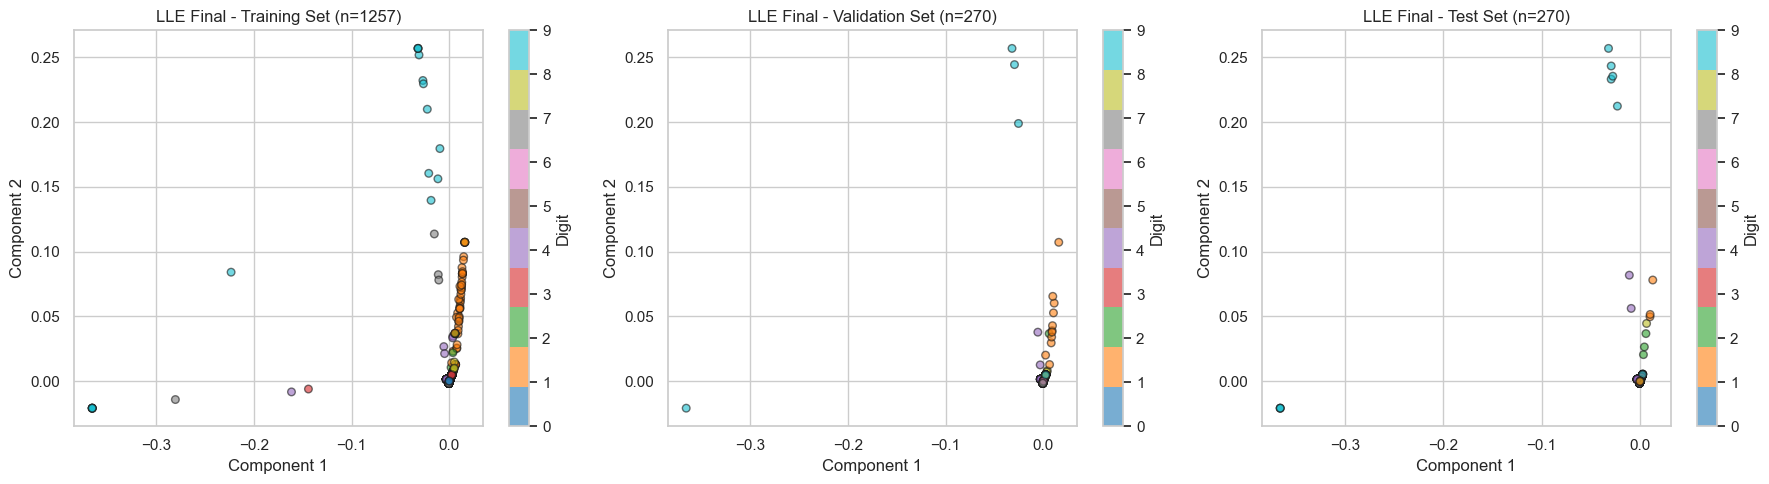

In [ ]:
# Final visualization: all three sets (train, val, test)
if best_n_components >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Extract train and val from the full reduced set
    X_train_reduced_final = X_train_full_reduced[:X_train.shape[0]]
    X_val_reduced_final = X_train_full_reduced[X_train.shape[0]:]
    
    # Training set (final model)
    scatter_train = axes[0].scatter(
        X_train_reduced_final[:, 0],
        X_train_reduced_final[:, 1],
        c=y_train,
        cmap='tab10',
        alpha=0.6,
        edgecolors='k',
        s=30
    )
    axes[0].set_xlabel(f'Component 1')
    axes[0].set_ylabel(f'Component 2')
    axes[0].set_title(f'LLE Final - Training Set (n={X_train.shape[0]})')
    plt.colorbar(scatter_train, ax=axes[0], label='Digit')
    
    # Validation set (final model)
    scatter_val = axes[1].scatter(
        X_val_reduced_final[:, 0],
        X_val_reduced_final[:, 1],
        c=y_val,
        cmap='tab10',
        alpha=0.6,
        edgecolors='k',
        s=30
    )
    axes[1].set_xlabel(f'Component 1')
    axes[1].set_ylabel(f'Component 2')
    axes[1].set_title(f'LLE Final - Validation Set (n={X_val.shape[0]})')
    plt.colorbar(scatter_val, ax=axes[1], label='Digit')
    
    # Test set (final model)
    scatter_test = axes[2].scatter(
        X_test_reduced[:, 0],
        X_test_reduced[:, 1],
        c=y_test,
        cmap='tab10',
        alpha=0.6,
        edgecolors='k',
        s=30
    )
    axes[2].set_xlabel(f'Component 1')
    axes[2].set_ylabel(f'Component 2')
    axes[2].set_title(f'LLE Final - Test Set (n={X_test.shape[0]})')
    plt.colorbar(scatter_test, ax=axes[2], label='Digit')
    
    plt.tight_layout()
    plt.show()
